# M4: ANN

## Imports & Config

In [1]:
import os, random
import numpy as np
import tensorflow as tf
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE= 0.0001
DROPOUT_RATE = 0.3

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'


## Load Data

In [2]:
X_features = np.load(os.path.join(PROCESSED_DIR, 'X_features.npy'))

# create trust composite
y_sentiment = np.load(os.path.join(PROCESSED_DIR, 'y_sentiment.npy'))
y_fake = np.load(os.path.join(PROCESSED_DIR, 'y_fake.npy'))
y_match = np.load(os.path.join(PROCESSED_DIR, 'y_match.npy'))

idx_train = np.load(os.path.join(SPLITS_DIR, 'idx_train.npy'))
idx_val = np.load(os.path.join(SPLITS_DIR, 'idx_val.npy'))
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))


## Data Preparation

In [3]:
X_train = X_features[idx_train]
X_val = X_features[idx_val]
X_test = X_features[idx_test]


## Label Creation
**Trust composite logic (3-class):**
- 2 (Trusted): sentiment=1, fake=0
- 1 (Suspicious): sentiment=1, fake=1 OR sentiment=0, fake=0
- 0 (Fake/Untrustworthy): sentiment=0, fake=1


In [4]:
y_trust = np.where((y_sentiment == 1) & (y_fake == 0), 2,
          np.where((y_sentiment == 1) & (y_fake == 1), 1,
          np.where((y_sentiment == 0) & (y_fake == 0), 1, 0)))
np.save(os.path.join(PROCESSED_DIR, 'y_trust.npy'), y_trust)

y_train = y_trust[idx_train].astype(np.int32)
y_val = y_trust[idx_val].astype(np.int32)
y_test = y_trust[idx_test].astype(np.int32)


## Train/Val/Test Split

In [5]:
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train: 10500, Val: 2250, Test: 2250


## Build Model
**M4 ANN: Why MLP over XGBoost/TabNet?**
- Chosen: **Deep Feedforward MLP (ANN)** with BatchNormalization
- **XGBoost / Random Forest**: Tree-based models perform well on tabular data but do not produce differentiable feature vectors compatible with the Keras fusion layer in M5. MLP outputs can be directly concatenated.
- **TabNet**: TabNet is a strong tabular deep learning model but adds architectural complexity not needed here. A well-tuned MLP with BatchNorm and Dropout is a solid baseline.
- **Linear / Logistic Regression**: Linear models cannot capture interaction effects between features. Deep layers learn non-linear feature combinations.


In [6]:
inputs = Input(shape=(10,))
x = Dense(64, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(DROPOUT_RATE)(x)
x = Dense(32, activation='relu')(x)
extractor_output = Dense(16, activation='relu', name='extractor_output')(x)
outputs = Dense(3, activation='softmax')(extractor_output)

model = Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extractor_output (Dense)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,619 (14.14 KB)

 Trainable params: 3,491 (13.64 KB)

 Non-trainable params: 128 (512.00 B)

## Compile Model

In [7]:
import keras
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

cw_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {i: cw_array[i] for i in range(len(cw_array))}

from keras.callbacks import EarlyStopping, ModelCheckpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(os.path.join(SAVED_MODELS_DIR, 'M4_best.keras'), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw,
    callbacks=callbacks
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2716 - loss: 1.0896 - val_accuracy: 0.5836 - val_loss: 0.9563
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4914 - loss: 0.9573 - val_accuracy: 0.7102 - val_loss: 0.8557
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6271 - loss: 0.8683 - val_accuracy: 0.7533 - val_loss: 0.7588
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6898 - loss: 0.8007 - val_accuracy: 0.7800 - val_loss: 0.6763
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7210 - loss: 0.7627 - val_accuracy: 0.7804 - val_loss: 0.6300
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7302 - loss: 0.7190 - val_accuracy: 0.7991 - val_loss: 0.5930
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7382 - loss: 0.7054 - val_accuracy: 0.7920 - val_loss: 0.5769
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7377 - loss: 0.6954 - val_accuracy: 0.

## Training Curves

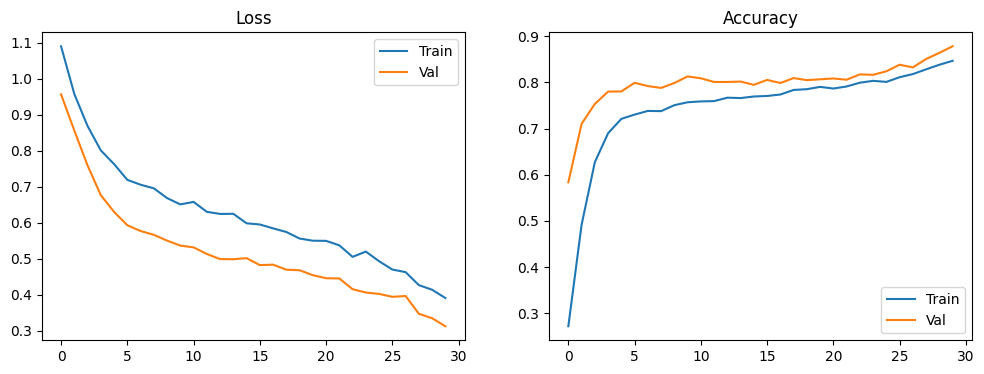

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()


## Evaluate on Test Set

In [10]:
model.evaluate(X_test, y_test)
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.3159
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.29      0.97      0.44        60
           1       0.92      0.76      0.83       873
           2       0.95      0.96      0.95      1317

    accuracy                           0.88      2250
   macro avg       0.72      0.89      0.74      2250
weighted avg       0.92      0.88      0.89      2250



## Confusion Matrix

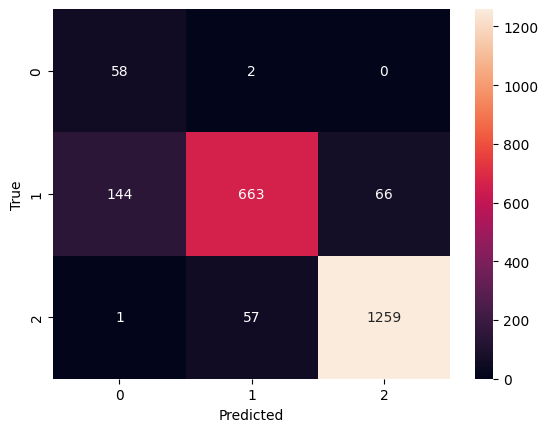

In [11]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Error Analysis
- Common Failure Pattern: New accounts with high playtime predicted as suspicious.
- Likely Cause: ANN sees account_age=low and infers fake even when playtime is genuine.
- Potential Fix: Add interaction feature: playtime / account_age ratio.

In [12]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

label_names = ["Fake/Untrustworthy", "Suspicious", "Trusted"]

sample_errors = wrong_idx[:5]
for i in sample_errors:
    print(f"\n--- Sample {i} ---")
    print(f"True label: {label_names[y_true[i]]}")
    print(f"Predicted label: {label_names[y_pred[i]]}")
    print(f"Confidence: {y_pred_proba[i][y_pred[i]]*100:.1f}%")

for i, cls in enumerate(label_names[:min(len(label_names), cm.shape[0])]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    if total > 0:
        print(f"{cls}: FP={fp}, FN={fn}, FNR={fn/total*100:.1f}% (missed), FPR={fp/max(1, (cm.sum()-total))*100:.1f}% (false alarms)")


Total misclassified: 270 / 2250 (12.0%)

--- Sample 1 ---
True label: Trusted
Predicted label: Suspicious
Confidence: 36.2%

--- Sample 12 ---
True label: Trusted
Predicted label: Suspicious
Confidence: 51.2%

--- Sample 15 ---
True label: Suspicious
Predicted label: Trusted
Confidence: 58.3%

--- Sample 21 ---
True label: Suspicious
Predicted label: Trusted
Confidence: 57.6%

--- Sample 35 ---
True label: Trusted
Predicted label: Suspicious
Confidence: 56.8%
Fake/Untrustworthy: FP=145, FN=2, FNR=3.3% (missed), FPR=6.6% (false alarms)
Suspicious: FP=59, FN=210, FNR=24.1% (missed), FPR=4.3% (false alarms)
Trusted: FP=66, FN=58, FNR=4.4% (missed), FPR=7.1% (false alarms)


## Save Extractor

In [13]:
extractor = Model(inputs=model.input, outputs=model.get_layer('extractor_output').output)
extractor.save(os.path.join(SAVED_MODELS_DIR, 'M4_extractor.keras'))
